# The Klatt-Engell CSTR: the infinite-horizon problem

The NMPC problem of Lueken, Brandner & Lucia (2023,
doi:10.1016/j.ifacol.2023.10.545) with the terminal cost replaced by
drto's terminal segment: one solve from an off-setpoint state, and a
training point read off the converged factorization.

[`models/klatt_engell.py`](models/klatt_engell.py) declares the reactor:
four states, two controls, and a tracking stage cost over all six with
Param weights. The steady solve below runs with the paper's weights
(the two concentrations at one, the rest at zero); after it writes the
equilibrium into the targets, every weight is set to one, so the
horizon problem tracks the computed equilibrium in every state and
control and the tail integrand vanishes there.

In [1]:
import pyomo.environ as pyo
from pyomo.contrib.solver.common.factory import SolverFactory as SF2
import pyomo_pounce  # registers the pounce solver with Pyomo

import drto
from models.klatt_engell import klatt_engell

m = klatt_engell(N=1, h=0.005, move_penalty=False)
drto.info(m)

<drto registry>
states: 4, controls: 2
declarations:
  horizon: t (ContinuousSet, 3 points)
  states: c_a (free), c_b (free), T_R (free), T_K (free)
  dynamics: dc_a[t]  ==  F[t]*(c_in - c_a[t]) - k0t*exp(- e1/(T_R[t] + 273.15))*c_a[t] - k0_3*exp(- e3/(T_R[t] + 273.15))*c_a[t]**2 + w_ca[t]  for t in t
  dynamics: dc_b[t]  ==  - F[t]*c_b[t] + k0t*exp(- e1/(T_R[t] + 273.15))*c_a[t] - k0_2*exp(- e2/(T_R[t] + 273.15))*c_b[t] + w_cb[t]  for t in t
  dynamics: dT_R[t]  ==  F[t]*(t_in - T_R[t]) + k_w*a_r/(rho*cp_r*v_r)*(T_K[t] - T_R[t]) - (k0t*exp(- e1/(T_R[t] + 273.15))*c_a[t]*dh1 + k0_2*exp(- e2/(T_R[t] + 273.15))*c_b[t]*dh2 + k0_3*exp(- e3/(T_R[t] + 273.15))*c_a[t]**2*dh3)/(rho*cp_r) + w_tr[t]  for t in t
  dynamics: dT_K[t]  ==  (Q_dot[t] + k_w*a_r*(T_R[t] - T_K[t]))/(m_k*cp_k) + w_tk[t]  for t in t
  controls: F (piecewise_constant, free), Q_dot (piecewise_constant, free)
  tracking stage cost: cost[t]  ==  q_ca*(c_a[t] - ca_sp)**2 + q_cb*(c_b[t] - cb_sp)**2 + q_tr*(T_R[t] - tr_sp)**2 + q_tk*(T_K[t] - tk_sp)**2 + r_f*(F[t] - f_sp)**2 + r_q*(Q_dot[t] - q_sp)**2  for t in sorted(t)[:-1]
  terminal cost: term  ==  q_ca*(c_a[0.005] - ca_sp)**2 + q_cb*(c_b[0.005] - cb_sp)**2 + q_tr*(T_R[0.005] - tr_sp)**2 + q_tk*(T_K[0.005] - tk_sp)**2
  initial conditions: c_a[0.0]  ==  ca_hat
  initial conditions: c_b[0.0]  ==  cb_hat
  initial conditions: T_R[0.0]  ==  tr_hat
  initial conditions: T_K[0.0]  ==  tk_hat
  steady-state targets: ca_sp (of c_a), cb_sp (of c_b), tr_sp (of T_R), tk_sp (of T_K)
  steady-state control targets: f_sp (of F), q_sp (of Q_dot)
  disturbances: w_ca (piecewise_constant), w_cb (piecewise_constant), w_tr (piecewise_constant), w_tk (piecewise_constant)
transformations: (none)

## The setpoint

The paper's setpoint pair is not an equilibrium of this reactor: k_1
and k_2 share their pre-exponential and activation energy, so holding
c_A = 0.7 and c_B = 0.6 at steady state forces a temperature far above
the 150 C bound, and a solve with both concentrations fixed converges
to local infeasibility. The steady point is instead chosen by the same
tracking cost: a clone is reduced, the controls left free, and the
reduced stage cost minimized over the steady states within bounds.

Every steady-state target takes the solution's values, the
concentration setpoints included: the tracking cost then vanishes at an
attainable equilibrium, which is the point the terminal segment pins.
The paper's 0.7 and 0.6 remain in the problem as the criterion that
selected it.

In [2]:
sm = pyo.TransformationFactory("drto.steady_state_optimization").create_using(m)
print(drto.initialize_steady_state(sm))
res = SF2("pounce").solve(sm, tee=True)
print("steady solve:", res.termination_condition.name)
print("steady cost:", pyo.value(sm.drto_objective))
print()

# each steady_state pairing names a component and its target Param; the
# reduced model's records line up by declaration order
reg, reg_s = drto.info(m), drto.info(sm)
for kind in ("steady_state", "steady_state_control"):
    for here, there in zip(reg.declarations(kind), reg_s.declarations(kind)):
        v = there["of"]
        value = pyo.value(next(iter(v.values())) if v.is_indexed() else v)
        here["component"].set_value(value)
        print(f"{here['component'].name} = {value:.6g}")

# with the equilibrium in the targets, every tracking term carries unit
# weight: the horizon problem tracks it in all four states and both
# controls
for w in (m.q_ca, m.q_cb, m.q_tr, m.q_tk, m.r_f, m.r_q):
    w.set_value(1.0)

pyomo-pounce initialize (fill -> repair -> block-solve)
  decisions held: 2
  values filled : 2
  projection    : optimal
  pyomo-pounce block_initialize
    decisions fixed   : 0
    system square     : True
    blocks solved     : 2 (1 by Newton 1x1, 1 subsystem solves)
    vars initialized  : 5
    left untouched    : 0 underdetermined, 0 overdetermined
********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclips

C:\Users\Devin\AppData\Local\Temp\tmpwn3j5hmq\unknowng6m47yo2.sol


steady solve: convergenceCriteriaSatisfied
steady cost: 7.60515262817298e-06

ca_sp = 0.701575
cb_sp = 0.597736
tr_sp = 140.82
tk_sp = 139.995
f_sp = 12.9428
q_sp = -715.563


## Assemble the horizon

The initial state is written into the `_hat` Params (the do-mpc
example's starting point). The terminal segment is appended, the
model cold-started from that state onto the targets, and the
optimization assembled. `drto.dynamic_optimization` declares the
initial-condition Params as pounce sensitivity parameters. The fitted
law's inputs are the four states.

In [3]:
# the initial state the horizon starts from (the do-mpc example's)
m.ca_hat.set_value(0.75)     # mol/L
m.cb_hat.set_value(0.75)     # mol/L
m.tr_hat.set_value(120)  # C
m.tk_hat.set_value(120)   # C

pyo.TransformationFactory("drto.infinite_horizon").apply_to(m, nfe=3, ncp=5)
drto.cold_start_dynamic(m, profile="exponential", time_constant=.3)
pyo.TransformationFactory("drto.dynamic_optimization").apply_to(m)
drto.info(m)

<drto registry>
states: 4, controls: 2
declarations:
  horizon: t (ContinuousSet, 3 points)
  states: c_a (free), c_b (free), T_R (free), T_K (free)
  dynamics: dc_a[t]  ==  F[t]*(c_in - c_a[t]) - k0t*exp(- e1/(T_R[t] + 273.15))*c_a[t] - k0_3*exp(- e3/(T_R[t] + 273.15))*c_a[t]**2 + w_ca[t]  for t in t
  dynamics: dc_b[t]  ==  - F[t]*c_b[t] + k0t*exp(- e1/(T_R[t] + 273.15))*c_a[t] - k0_2*exp(- e2/(T_R[t] + 273.15))*c_b[t] + w_cb[t]  for t in t
  dynamics: dT_R[t]  ==  F[t]*(t_in - T_R[t]) + k_w*a_r/(rho*cp_r*v_r)*(T_K[t] - T_R[t]) - (k0t*exp(- e1/(T_R[t] + 273.15))*c_a[t]*dh1 + k0_2*exp(- e2/(T_R[t] + 273.15))*c_b[t]*dh2 + k0_3*exp(- e3/(T_R[t] + 273.15))*c_a[t]**2*dh3)/(rho*cp_r) + w_tr[t]  for t in t
  dynamics: dT_K[t]  ==  (Q_dot[t] + k_w*a_r*(T_R[t] - T_K[t]))/(m_k*cp_k) + w_tk[t]  for t in t
  controls: F (piecewise_constant, free), Q_dot (piecewise_constant, free)
  tracking stage cost: cost[t]  ==  q_ca*(c_a[t] - ca_sp)**2 + q_cb*(c_b[t] - cb_sp)**2 + q_tr*(T_R[t] - tr_sp)**2 + q_tk*(T_K[t] - tk_sp)**2 + r_f*(F[t] - f_sp)**2 + r_q*(Q_dot[t] - q_sp)**2  for t in sorted(t)[:-1]
  terminal cost: term  ==  q_ca*(c_a[0.005] - ca_sp)**2 + q_cb*(c_b[0.005] - cb_sp)**2 + q_tr*(T_R[0.005] - tr_sp)**2 + q_tk*(T_K[0.005] - tk_sp)**2
  initial conditions: c_a[0.0]  ==  ca_hat
  initial conditions: c_b[0.0]  ==  cb_hat
  initial conditions: T_R[0.0]  ==  tr_hat
  initial conditions: T_K[0.0]  ==  tk_hat
  steady-state targets: ca_sp (of c_a), cb_sp (of c_b), tr_sp (of T_R), tk_sp (of T_K)
  steady-state control targets: f_sp (of F), q_sp (of Q_dot)
  disturbances: w_ca (piecewise_constant), w_cb (piecewise_constant), w_tr (piecewise_constant), w_tk (piecewise_constant)
  cost_group: drto_ih, drto_ih
transformations:
  drto.infinite_horizon: segment=3 elements x 5 Legendre points, beta=1.2, gamma=3.12765494, profile=collocation, horizon=kept, infinite tail appended, disturbances=w_ca fixed at 0.0, w_cb fixed at 0.0, w_tr fixed at 0.0, w_tk fixed at 0.0, terminal_cost=terminal deactivated (the tail owns it), terminal=soft pin z(tau=1)=z_s on 4 states, mu=1000.0
  drto.parameterize: profiles=F (piecewise_constant), Q_dot (piecewise_constant), w_ca (piecewise_constant), w_cb (piecewise_constant), w_tr (piecewise_constant), w_tk (piecewise_constant)
  drto.build_objective: objective=sum of 32 weighted cost terms
  drto.dynamic_optimization: horizon=kept, tracking_weight=(one stage cost declared), disturbances=w_ca=0, w_cb=0, w_tr=0, w_tk=0, sensitivity=4 initial-condition Params declared

## Solve

From the do-mpc example's initial state, written into the `_hat`
Params at assembly, toward the paper's setpoints c_A = 0.7,
c_B = 0.6 mol/L.

In [4]:
res = SF2("pounce").solve(m, tee=True)
print(res.termination_condition.name)
print("objective", pyo.value(m.drto_objective))

********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) — drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.10.0, running with linear solver FERAL.



Number of nonzeros in equality constraint Jacobian...:      917
Number of nonzeros in inequality constraint Jacobian.:       40
Number of nonzeros in Lagrangian Hessian.............:      198

Total number of variables............................:      205
                     variables with only lower bounds:        8
                variables with lower and upper bounds:      120
                     variables with only upper bounds:        0
Total number of equality constraints.................:      169
Total number of inequality constraints...............:        8
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        8
        inequality constraints with only upper bounds:        0

iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
   0  9.3523418e+02 4.14e+03 1.01e+02   -1.0 0.00e+00      - 0.00e+00 0.00e+00   0
   1  8.7398176e+02 4.00e+03 9.85e+01   -1.0 4.26e+03      - 1.4

convergenceCriteriaSatisfied
objective 8884.39488607774


## One training point

The label is the first control action, and the objective is the
cost-to-go from the `_hat` state; the gradient half is the action's
derivative with respect to the initial state, read from the solve's
converged factorization through
`drto.advanced_step_controller(m, gradient=True)`.

In [5]:
t0 = m.t.first()
grads = drto.advanced_step_controller(m, gradient=True)
for u in (m.F, m.Q_dot):
    print(f"{u.name}[0] = {pyo.value(u[t0]):.6g}")
    for p, g in grads[u].items():
        print(f"  d{u.name}[0]/d{p.name} = {g[u[t0], p]:.6g}")

F[0] = 33.9561
  dF[0]/dca_hat = -0.772549
  dF[0]/dcb_hat = -1.80919
  dF[0]/dtr_hat = -1.12145
  dF[0]/dtk_hat = -0.200229
Q_dot[0] = -715.505
  dQ_dot[0]/dca_hat = -0.00161395
  dQ_dot[0]/dcb_hat = -0.000469408
  dQ_dot[0]/dtr_hat = -0.000949226
  dQ_dot[0]/dtk_hat = -0.000751104


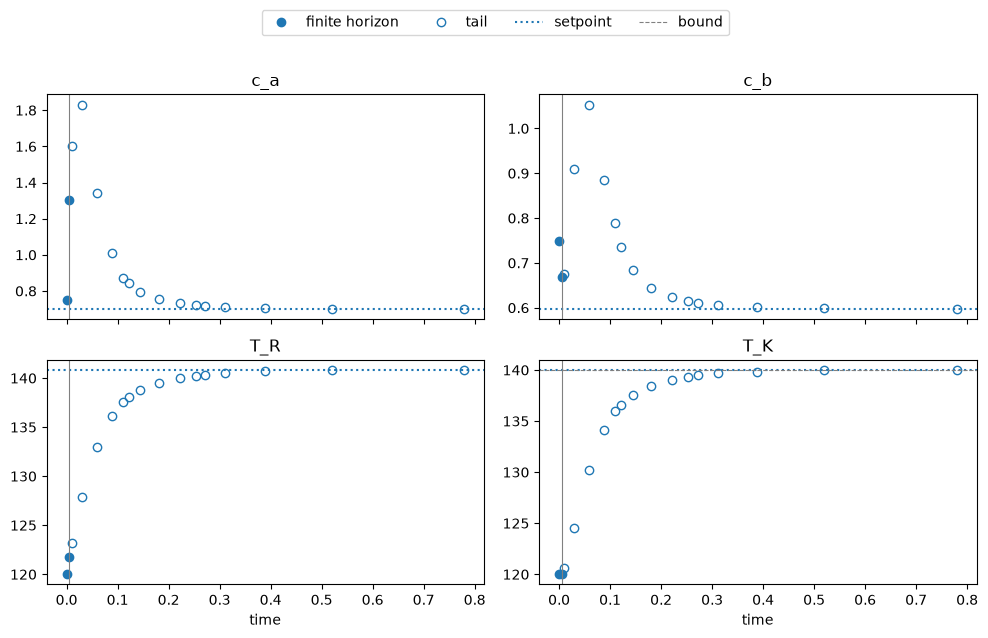

In [6]:
axes = drto.plot_states(m)

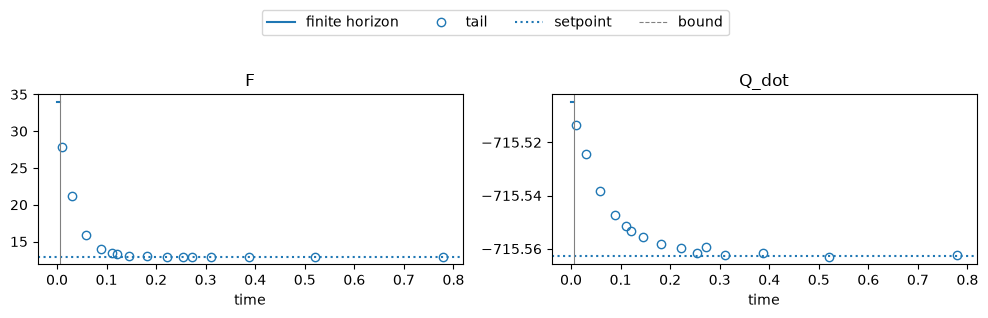

In [7]:
axes = drto.plot_controls(m)

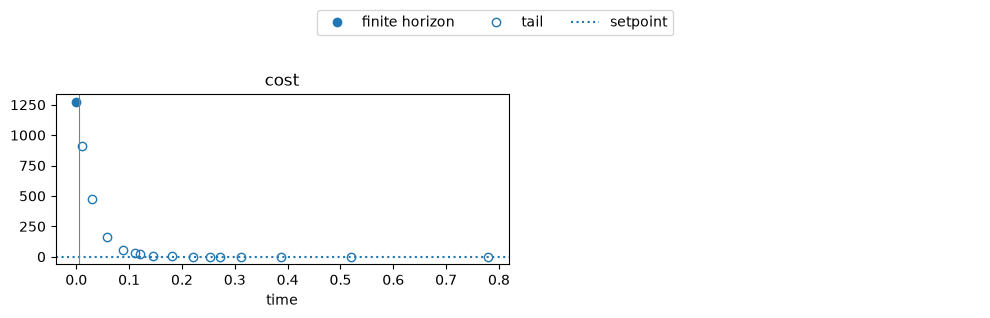

In [8]:
axes = drto.plot_stage_cost(m)